## Question 3

### Install pgmpy https://pgmpy.org/, and daft-pgm https://docs.daft-pgm.org/

In [1]:
!pip install pgmpy
!pip install daft-pgm

In [2]:
# Import relevant packages
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt

INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [3]:
# (3a) Create the BN model for the DAG graph given in Question 2

# write your code here [1 point]
model = DiscreteBayesianNetwork([
    ('B', 'A'),
    ('E', 'A'),
    ('A', 'J'),
    ('A', 'M')
])

print("Nodes:", model.nodes())
print("Edges:", model.edges())


Nodes: ['B', 'A', 'E', 'J', 'M']
Edges: [('B', 'A'), ('A', 'J'), ('A', 'M'), ('E', 'A')]


In [ ]:
# (3b) Add all CPDs (given in Question 2) to the model

# write your code here [3 points]

cpd_B = TabularCPD( variable='B', variable_card=2, values=[[0.999],[0.001]])

cpd_E = TabularCPD(variable='E', variable_card=2, values=[[0.998],[0.002]])

### CPD for A|B, E
# when row 0 = A=0, Row 1 = A=1
cpd_A = TabularCPD(
    variable='A',
    variable_card=2,
    values=[[0.999, 0.71, 0.06, 0.05], [0.001, 0.29, 0.94, 0.95]],   
    evidence=['B', 'E'],
    evidence_card=[2, 2]
)

### CPD for J |A
cpd_J = TabularCPD(
    variable='J',
    variable_card=2,
    values=[[0.95, 0.10],  [0.05, 0.90]],  evidence=['A'],
    evidence_card=[2]
)

##$ CPD for M|A
cpd_M = TabularCPD(
    variable='M',
    variable_card=2,
    values=[[0.99, 0.30],   
            [0.01, 0.70]], 
    evidence=['A'],
    evidence_card=[2]
)

# add all CPDs
model.add_cpds(cpd_B, cpd_E, cpd_A, cpd_J, cpd_M)

print("CPD for B:","\n", cpd_B)
print("\nCPD for E:","\n",cpd_E)
print("\nCPD for A | B, E:","\n",cpd_A)
print("\nCPD for J | A:","\n",cpd_J)
print("\nCPD for M | A:","\n",cpd_M)

CPD for B: 
 +------+-------+
| B(0) | 0.999 |
+------+-------+
| B(1) | 0.001 |
+------+-------+

CPD for E: 
 +------+-------+
| E(0) | 0.998 |
+------+-------+
| E(1) | 0.002 |
+------+-------+

CPD for A | B, E: 
 +------+-------+------+------+------+
| B    | B(0)  | B(0) | B(1) | B(1) |
+------+-------+------+------+------+
| E    | E(0)  | E(1) | E(0) | E(1) |
+------+-------+------+------+------+
| A(0) | 0.999 | 0.71 | 0.06 | 0.05 |
+------+-------+------+------+------+
| A(1) | 0.001 | 0.29 | 0.94 | 0.95 |
+------+-------+------+------+------+

CPD for J | A: 
 +------+------+------+
| A    | A(0) | A(1) |
+------+------+------+
| J(0) | 0.95 | 0.1  |
+------+------+------+
| J(1) | 0.05 | 0.9  |
+------+------+------+

CPD for M | A: 
 +------+------+------+
| A    | A(0) | A(1) |
+------+------+------+
| M(0) | 0.99 | 0.3  |
+------+------+------+
| M(1) | 0.01 | 0.7  |
+------+------+------+


Model is valid: True


/var/folders/gl/lgxp7xr150n09fzxwspxh19w0000gn/T/ipykernel_40483/2284357160.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


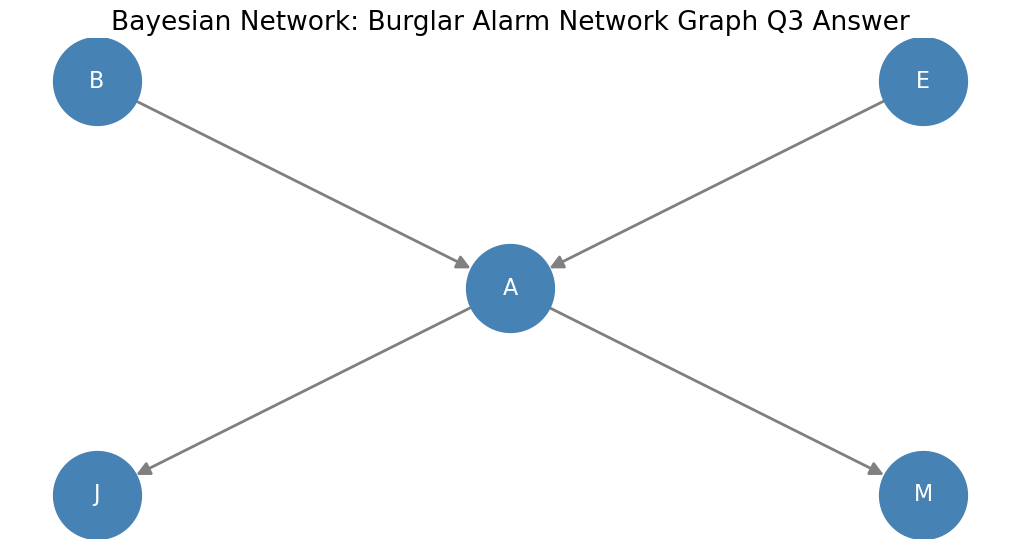

Graph saved as bn_graph.png


In [ ]:
# (3c) Perform a model check and plot your Bayesian network graph

# write your code here [2 points]
is_valid = model.check_model()
print(f"Model is valid: {is_valid}")

import networkx as nx

G = nx.DiGraph(model.edges())
pos = {
    'B': (0, 2),
    'E': (2, 2),
    'A': (1, 1),
    'J': (0, 0),
    'M': (2, 0)
}

plt.figure(figsize=(10, 5))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=4000, font_color='white', font_size=16,
        arrows=True, arrowsize=20, edge_color='gray', width=2)
plt.title("Bayesian Network: Burglar Alarm Network Graph Q3 Answer", fontsize=19)
plt.tight_layout()
plt.savefig('bn_graph.png', dpi=100)
plt.show()
print("Graph saved as bn_graph.png")

In [ ]:
# (3d) Perform inference using VariableElimination to verify your final results for Question 2, i.e., P(J) and P(B | M=1).

# write your code here [2 points]
infer = VariableElimination(model)

# p(J) - marginal inference
result_J = infer.query(variables=['J'], show_progress=False)
print("P(J):")
print(result_J)
print(f"  P(J=0) = {result_J.values[0]:.9f}")
print(f"  P(J=1) = {result_J.values[1]:.9f}")
print("\n")
# p(B |M=1) - posterior inference
result_B = infer.query(variables=['B'], evidence={'M': 1}, show_progress=False)
print("P(B | M=1):")
print(result_B)
print(f"  P(B=0|M=1) = {result_B.values[0]:.9f}")
print(f"  P(B=1|M=1) = {result_B.values[1]:.9f}")


P(J):
+------+----------+
| J    |   phi(J) |
+======+==========+
| J(0) |   0.9479 |
+------+----------+
| J(1) |   0.0521 |
+------+----------+
  P(J=0) = 0.947861024
  P(J=1) = 0.052138976
  Expected: P(J=0)=0.945076282, P(J=1)=0.054923719


P(B | M=1):
+------+----------+
| B    |   phi(B) |
+======+==========+
| B(0) |   0.9439 |
+------+----------+
| B(1) |   0.0561 |
+------+----------+
  P(B=0|M=1) = 0.943882546
  P(B=1|M=1) = 0.056117454
  Expected: P(B=0|M=1)=0.76472871, P(B=1|M=1)=0.23527129
